# Memory and Communication Profiling for MixFedMoE

This notebook profiles:
1. **Peak VRAM** during training for each method, when CUDA profiling is enabled
2. **Download and upload communication** per client per round
3. **Download and upload parameter counts** for the communication protocol

Methods are reported with paper labels: FedAvg-Full, FedMoE, FLEx, and Fed-M$^2$oE (Ours).

In [10]:
from pathlib import Path
import sys
import gc
from typing import Any, Dict, List, Optional, Sequence, Tuple

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether this notebook is launched from repo root or shells/notebooks.
NOTEBOOK_CWD = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_CWD
for candidate in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents]:
    if (candidate / "mixfedmoe_fl").exists():
        REPO_ROOT = candidate
        break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from mixfedmoe_fl.config import MixFedMoEConfig
from mixfedmoe_fl.client import (
    collect_moe_handles,
    apply_mode_full,
    apply_mode_mix,
    apply_mode_drop,
    get_expert_entries,
)
from models.switch_transformers import SwitchTransformersForSequenceClassification

# Set default device and skip CUDA-only profiling automatically on CPU machines.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AUTO_SKIP_MEMORY_PROFILING = not torch.cuda.is_available()
SKIP_MEMORY_PROFILING = AUTO_SKIP_MEMORY_PROFILING
print(f"Repo root: {REPO_ROOT}")
print(f"Using device: {device}")
print(f"Skip memory profiling: {SKIP_MEMORY_PROFILING}")

Repo root: C:\Users\Administrator\Desktop\mixfedmoe
Using device: cpu
Skip memory profiling: True


## Configuration

Using default settings from config.py

In [11]:
MODEL_PATH = REPO_ROOT / "model_ckpt" / "switch-base-8"

# Default configuration matching config.py defaults.
config = MixFedMoEConfig(
    mode="full",  # Overridden for each method.
    model_name_or_path=str(MODEL_PATH),
    dataset_name="ag_news",
    num_clients=8,
    num_rounds=100,
    k=4,
    alpha=0.5,
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    local_epochs=1.0,
    learning_rate=2e-5,
    weight_decay=0.0,
    train_batch_size=16,
    eval_batch_size=16,
    max_length=256,
    client_eval_ratio=0.5,
    seed=42,
    num_cpus_per_client=4,
    num_gpus_per_client=1,
    output_dir="outputs/profiling",
    test_samples=1000,
    assignment_policy="hot",
)

# Dummy input dimensions used only when CUDA memory profiling is enabled.
BATCH_SIZE = 1
SEQ_LENGTH = 256
NUM_LABELS = 4  # ag_news has 4 classes

# If memory profiling is skipped, use the measured VRAM values from the paper run.
# Set USE_MEMORY_OVERRIDES=False to leave Peak VRAM blank when profiling is skipped.
USE_MEMORY_OVERRIDES = True
PEAK_MEMORY_OVERRIDES_MB = {
    "full": 9336.79,
    "drop": 3313.36,
    "flex": 864.94,
    "mix": 3313.92,
}
WALL_TIME_MINUTES = {
    "full": 200.93,
    "drop": 108.15,
    "flex": 42.33,
    "mix": 111.37,
}

MODE_SPECS = [
    {"mode": "full", "label": "FedAvg-Full", "k": config.k},
    {"mode": "drop", "label": "FedMoE", "k": config.k},
    {"mode": "flex", "label": "FLEx", "k": 1},
    {"mode": "mix", "label": "Ours", "k": config.k},
]

print(f"Model path: {config.model_name_or_path}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Sequence length: {SEQ_LENGTH}")
print(f"Number of labels: {NUM_LABELS}")
print(f"Default K (experts per client): {config.k}")

Model path: C:\Users\Administrator\Desktop\mixfedmoe\model_ckpt\switch-base-8
Batch size: 1
Sequence length: 256
Number of labels: 4
Default K (experts per client): 4


## Helper Functions

In [12]:
def tensor_mb(numel: int, element_size: int) -> float:
    return numel * element_size / (1024**2)


def param_bytes(items: Sequence[Tuple[str, nn.Parameter]]) -> int:
    return sum(param.numel() * param.element_size() for _, param in items)


def param_count(items: Sequence[Tuple[str, nn.Parameter]]) -> int:
    return sum(param.numel() for _, param in items)


def is_expert_param(name: str) -> bool:
    return "expert" in name


def is_router_param(name: str) -> bool:
    return "router" in name or ".gate." in name


def get_model_info(model: nn.Module) -> Dict[str, Any]:
    """Get parameter counts and actual dtype-aware parameter memory."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    param_info = []
    for name, param in model.named_parameters():
        size_mb = tensor_mb(param.numel(), param.element_size())
        param_info.append({
            "name": name,
            "shape": list(param.shape),
            "numel": param.numel(),
            "dtype": str(param.dtype),
            "element_size": param.element_size(),
            "requires_grad": param.requires_grad,
            "size_mb": size_mb,
            "trainable_mb": size_mb if param.requires_grad else 0.0,
        })

    return {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "total_mb": sum(p["size_mb"] for p in param_info),
        "trainable_mb": sum(p["trainable_mb"] for p in param_info),
        "param_details": param_info,
    }


def measure_peak_memory(model: nn.Module, input_ids: torch.Tensor, attention_mask: torch.Tensor, labels: torch.Tensor) -> float:
    """Measure peak CUDA memory during one forward/backward/optimizer step."""
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available; set SKIP_MEMORY_PROFILING=True on CPU machines.")

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()
    baseline = torch.cuda.memory_allocated()

    model.train()
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=2e-5)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels,
        use_cache=False,
        return_dict=True,
    )
    outputs.loss.backward()
    optimizer.step()

    peak_memory = (torch.cuda.max_memory_allocated() - baseline) / (1024**2)

    del optimizer
    model.zero_grad(set_to_none=True)
    return peak_memory


def calculate_communication_cost(model: nn.Module, mode: str, k: int) -> Dict[str, Any]:
    """Calculate per-client communication under the paper protocol.

    Sparse methods always transmit shared non-expert parameters in FP32, including attention,
    embeddings/lm-head-style shared weights, and classification parameters. Experts are handled
    according to each method.

    Full/FedAvg-Full: download and upload every FP32 parameter.
    Drop/FedMoE: download and upload shared FP32 params plus active FP32 experts.
    Flex/FLEx: Drop with K=1.
    Mix/Ours: download shared FP32 params, hot FP32 experts, and BF16 cold experts;
    upload shared FP32 params plus hot FP32 experts.
    """
    named_params = list(model.named_parameters())
    shared_items = [(name, param) for name, param in named_params if not is_expert_param(name)]
    hot_expert_items = [
        (name, param)
        for name, param in named_params
        if is_expert_param(name) and param.requires_grad
    ]
    cold_expert_items = [
        (name, param)
        for name, param in named_params
        if is_expert_param(name) and not param.requires_grad
    ]

    if mode == "full":
        download_fp32_items = named_params
        download_bf16_items: List[Tuple[str, nn.Parameter]] = []
        upload_fp32_items = named_params
        download_policy = "full FP32 model"
        upload_policy = "full FP32 model"
    elif mode == "mix":
        download_fp32_items = shared_items + hot_expert_items
        download_bf16_items = cold_expert_items
        upload_fp32_items = shared_items + hot_expert_items
        download_policy = "shared FP32 params + hot FP32 experts + BF16 cold experts"
        upload_policy = "shared FP32 params + hot FP32 experts"
    elif mode in {"drop", "flex"}:
        download_fp32_items = shared_items + hot_expert_items
        download_bf16_items = []
        upload_fp32_items = shared_items + hot_expert_items
        download_policy = "shared FP32 params + active FP32 experts"
        upload_policy = "shared FP32 params + active FP32 experts"
    else:
        raise ValueError(f"Unsupported mode: {mode}")

    download_bytes = param_bytes(download_fp32_items) + param_bytes(download_bf16_items)
    upload_bytes = param_bytes(upload_fp32_items)
    download_param_names = {name for name, _ in download_fp32_items + download_bf16_items}
    excluded_items = [(name, param) for name, param in named_params if name not in download_param_names]

    return {
        "mode": mode,
        "k": k,
        "download_mb": download_bytes / (1024**2),
        "upload_mb": upload_bytes / (1024**2),
        "total_communication_mb": (download_bytes + upload_bytes) / (1024**2),
        "download_params": param_count(download_fp32_items) + param_count(download_bf16_items),
        "upload_params": param_count(upload_fp32_items),
        "download_fp32_params": param_count(download_fp32_items),
        "download_bf16_params": param_count(download_bf16_items),
        "upload_fp32_params": param_count(upload_fp32_items),
        "download_fp32_mb": param_bytes(download_fp32_items) / (1024**2),
        "download_bf16_mb": param_bytes(download_bf16_items) / (1024**2),
        "upload_fp32_mb": upload_bytes / (1024**2),
        "excluded_params": param_count(excluded_items),
        "excluded_mb": param_bytes(excluded_items) / (1024**2),
        "compression_ratio": upload_bytes / download_bytes if download_bytes > 0 else np.nan,
        "download_policy": download_policy,
        "upload_policy": upload_policy,
    }


def create_layer_hot_map(moe_handles: Sequence[Any], k: int, mode: str) -> Dict[str, List[int]]:
    """Create a deterministic layer hot map for profiling."""
    layer_hot_map: Dict[str, List[int]] = {}
    for handle in moe_handles:
        entries = get_expert_entries(handle.mlp_module, handle.experts_attr)
        num_experts = len(entries)
        if mode == "full":
            layer_hot_map[handle.layer_id] = list(range(num_experts))
        else:
            layer_hot_map[handle.layer_id] = list(range(min(k, num_experts)))
    return layer_hot_map


def create_dummy_inputs(model: nn.Module, batch_size: int, seq_length: int, num_labels: int, target_device: torch.device):
    """Create dummy inputs with proper EOS tokens for the model."""
    dummy_input_ids = torch.randint(0, model.config.vocab_size, (batch_size, seq_length), device=target_device)
    eos_token_id = model.config.eos_token_id if model.config.eos_token_id is not None else 1
    dummy_input_ids[:, -1] = eos_token_id
    dummy_attention_mask = torch.ones(batch_size, seq_length, device=target_device)
    dummy_labels = torch.randint(0, num_labels, (batch_size,), device=target_device)
    return dummy_input_ids, dummy_attention_mask, dummy_labels


def get_peak_memory_value(mode: str, model: nn.Module) -> Optional[float]:
    if SKIP_MEMORY_PROFILING:
        if USE_MEMORY_OVERRIDES:
            return PEAK_MEMORY_OVERRIDES_MB.get(mode)
        return None

    model.to(device)
    dummy_input_ids, dummy_attention_mask, dummy_labels = create_dummy_inputs(
        model, BATCH_SIZE, SEQ_LENGTH, NUM_LABELS, device
    )
    return measure_peak_memory(model, dummy_input_ids, dummy_attention_mask, dummy_labels)


def profile_mode(mode: str, label: str, k: int, config: MixFedMoEConfig) -> Dict[str, Any]:
    """Profile a single method."""
    print(f"\n{'='*70}")
    print(f"Profiling method: {label} (mode={mode}, K={k})")
    print(f"{'='*70}")

    print("Loading model...")
    model = SwitchTransformersForSequenceClassification.from_pretrained(
        config.model_name_or_path,
        num_labels=NUM_LABELS,
        ignore_mismatched_sizes=True,
        torch_dtype=torch.float32,
        tie_word_embeddings=False,
    )
    model.config.use_cache = False

    moe_handles = collect_moe_handles(model)
    if not moe_handles:
        raise RuntimeError("No MoE layers with experts were detected in the model.")
    experts_per_layer = {
        handle.layer_id: len(get_expert_entries(handle.mlp_module, handle.experts_attr))
        for handle in moe_handles
    }
    print(f"Found {len(moe_handles)} MoE layers")
    print(f"Experts per layer: {list(experts_per_layer.values())[:3]}... (showing first 3)")

    apply_mode = "drop" if mode == "flex" else mode
    layer_hot_map = create_layer_hot_map(moe_handles, k, apply_mode)

    if mode == "full":
        apply_mode_full(model)
    elif mode == "mix":
        apply_mode_mix(model, moe_handles, layer_hot_map)
    elif mode in {"drop", "flex"}:
        apply_mode_drop(model, moe_handles, layer_hot_map)
    else:
        raise ValueError(f"Unsupported mode: {mode}")

    model_info = get_model_info(model)
    print("\nModel Info:")
    print(f"  Total parameters: {model_info['total_params']:,}")
    print(f"  Trainable parameters: {model_info['trainable_params']:,}")
    print(f"  Dtype-aware model size: {model_info['total_mb']:.2f} MB")
    print(f"  Trainable size: {model_info['trainable_mb']:.2f} MB")
    print(f"  Trainable ratio: {model_info['trainable_params'] / model_info['total_params'] * 100:.2f}%")

    if SKIP_MEMORY_PROFILING:
        peak_memory_mb = get_peak_memory_value(mode, model)
        if peak_memory_mb is None:
            print("\nSkipping CUDA peak memory profiling; Peak VRAM will be blank.")
        else:
            print(f"\nSkipping CUDA profiling; using Peak VRAM override: {peak_memory_mb:.2f} MB")
    else:
        print(f"\nMeasuring peak memory on {device}...")
        peak_memory_mb = get_peak_memory_value(mode, model)
        print(f"  Peak memory: {peak_memory_mb:.2f} MB")

    comm_info = calculate_communication_cost(model, mode, k)
    print("\nCommunication Cost:")
    print(f"  Download policy: {comm_info['download_policy']}")
    print(f"  Upload policy: {comm_info['upload_policy']}")
    print(f"  Download params: {comm_info['download_params']:,}")
    print(f"  Upload params: {comm_info['upload_params']:,}")
    print(f"  Download (server -> client): {comm_info['download_mb']:.2f} MB")
    print(f"  Upload (client -> server): {comm_info['upload_mb']:.2f} MB")
    print(f"  Total per round: {comm_info['total_communication_mb']:.2f} MB")
    print(f"  Upload/download ratio: {comm_info['compression_ratio']:.4f}")

    model.cpu()
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "mode": mode,
        "mode_label": label,
        "k": k,
        "model_info": model_info,
        "peak_memory_mb": peak_memory_mb,
        "wall_time_minutes": WALL_TIME_MINUTES.get(mode),
        "communication": comm_info,
    }

## Profile All Methods

In [13]:
results: Dict[str, Dict[str, Any]] = {}

for spec in MODE_SPECS:
    try:
        results[spec["mode"]] = profile_mode(
            mode=spec["mode"],
            label=spec["label"],
            k=spec["k"],
            config=config,
        )
    except Exception as e:
        print(f"Error profiling {spec['label']} ({spec['mode']}): {e}")
        import traceback
        traceback.print_exc()


Profiling method: FedAvg-Full (mode=full, K=4)
Loading model...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

SwitchTransformersForSequenceClassification LOAD REPORT from: C:\Users\Administrator\Desktop\mixfedmoe\model_ckpt\switch-base-8
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.weight                      | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Found 12 MoE layers
Experts per layer: [8, 8, 8]... (showing first 3)

Model Info:
  Total parameters: 668,690,692
  Trainable parameters: 668,690,692
  Dtype-aware model size: 2550.85 MB
  Trainable size: 2550.85 MB
  Trainable ratio: 100.00%

Skipping CUDA profiling; using Peak VRAM override: 9336.79 MB

Communication Cost:
  Download policy: full FP32 model
  Upload policy: full FP32 model
  Download params: 668,690,692
  Upload params: 668,690,692
  Download (server -> client): 2550.85 MB
  Upload (client -> server): 2550.85 MB
  Total per round: 5101.71 MB
  Upload/download ratio: 1.0000

Profiling method: FedMoE (mode=drop, K=4)
Loading model...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

...

SwitchTransformersForSequenceClassification LOAD REPORT from: C:\Users\Administrator\Desktop\mixfedmoe\model_ckpt\switch-base-8
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.weight                      | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Found 12 MoE layers
Experts per layer: [8, 8, 8]... (showing first 3)

Model Info:
  Total parameters: 272,264,452
  Trainable parameters: 81,309,700
  Dtype-aware model size: 1038.61 MB
  Trainable size: 310.17 MB
  Trainable ratio: 29.86%

Skipping CUDA profiling; using Peak VRAM override: 864.94 MB

Communication Cost:
  Download policy: shared FP32 params + active FP32 experts
  Upload policy: shared FP32 params + active FP32 experts
  Download params: 272,264,452
  Upload params: 272,264,452
  Download (server -> client): 1038.61 MB
  Upload (client -> server): 1038.61 MB
  Total per round: 2077.21 MB
  Upload/download ratio: 1.0000

Profiling method: Ours (mode=mix, K=4)
Loading model...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

SwitchTransformersForSequenceClassification LOAD REPORT from: C:\Users\Administrator\Desktop\mixfedmoe\model_ckpt\switch-base-8
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.weight                      | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Found 12 MoE layers
Experts per layer: [8, 8, 8]... (showing first 3)

Model Info:
  Total parameters: 668,690,692
  Trainable parameters: 251,243,524
  Dtype-aware model size: 2118.85 MB
  Trainable size: 958.42 MB
  Trainable ratio: 37.57%

Skipping CUDA profiling; using Peak VRAM override: 3313.92 MB

Communication Cost:
  Download policy: shared FP32 params + hot FP32 experts + BF16 cold experts
  Upload policy: shared FP32 params + hot FP32 experts
  Download params: 668,690,692
  Upload params: 442,198,276
  Download (server -> client): 2118.85 MB
  Upload (client -> server): 1686.85 MB
  Total per round: 3805.71 MB
  Upload/download ratio: 0.7961


## Summary Table

In [14]:
summary_data = []

for spec in MODE_SPECS:
    mode = spec["mode"]
    if mode not in results:
        continue
    result = results[mode]
    comm = result["communication"]
    summary_data.append({
        "Mode": result["mode_label"],
        "K": result["k"],
        "Total Params (M)": result["model_info"]["total_params"] / 1e6,
        "Trainable Params (M)": result["model_info"]["trainable_params"] / 1e6,
        "Trainable %": result["model_info"]["trainable_params"] / result["model_info"]["total_params"] * 100,
        "Model Size (MB)": result["model_info"]["total_mb"],
        "Trainable Size (MB)": result["model_info"]["trainable_mb"],
        "Peak VRAM (MB)": result["peak_memory_mb"],
        "Download Params (M)": comm["download_params"] / 1e6,
        "Upload Params (M)": comm["upload_params"] / 1e6,
        "Download (MB)": comm["download_mb"],
        "Upload (MB)": comm["upload_mb"],
        "Total Comm (MB/Round)": comm["total_communication_mb"],
        "Upload/Download": comm["compression_ratio"],
        "Total Wall Time (Minutes)": result["wall_time_minutes"],
    })

summary_df = pd.DataFrame(summary_data)
print("\nSummary Table:")
print("=" * 140)
print(summary_df.to_string(index=False, float_format="%.2f"))


Summary Table:
       Mode  K  Total Params (M)  Trainable Params (M)  Trainable %  Model Size (MB)  Trainable Size (MB)  Peak VRAM (MB)  Download Params (M)  Upload Params (M)  Download (MB)  Upload (MB)  Total Comm (MB/Round)  Upload/Download  Total Wall Time (Minutes)
FedAvg-Full  4            668.69                668.69       100.00          2550.85              2550.85         9336.79               668.69             668.69        2550.85      2550.85                5101.71             1.00                     200.93
     FedMoE  4            442.16                251.21        56.81          1686.71               958.28         3313.36               442.16             442.16        1686.71      1686.71                3373.42             1.00                     108.15
       FLEx  1            272.26                 81.31        29.86          1038.61               310.17          864.94               272.26             272.26        1038.61      1038.61                2077.21 

## Visualizations

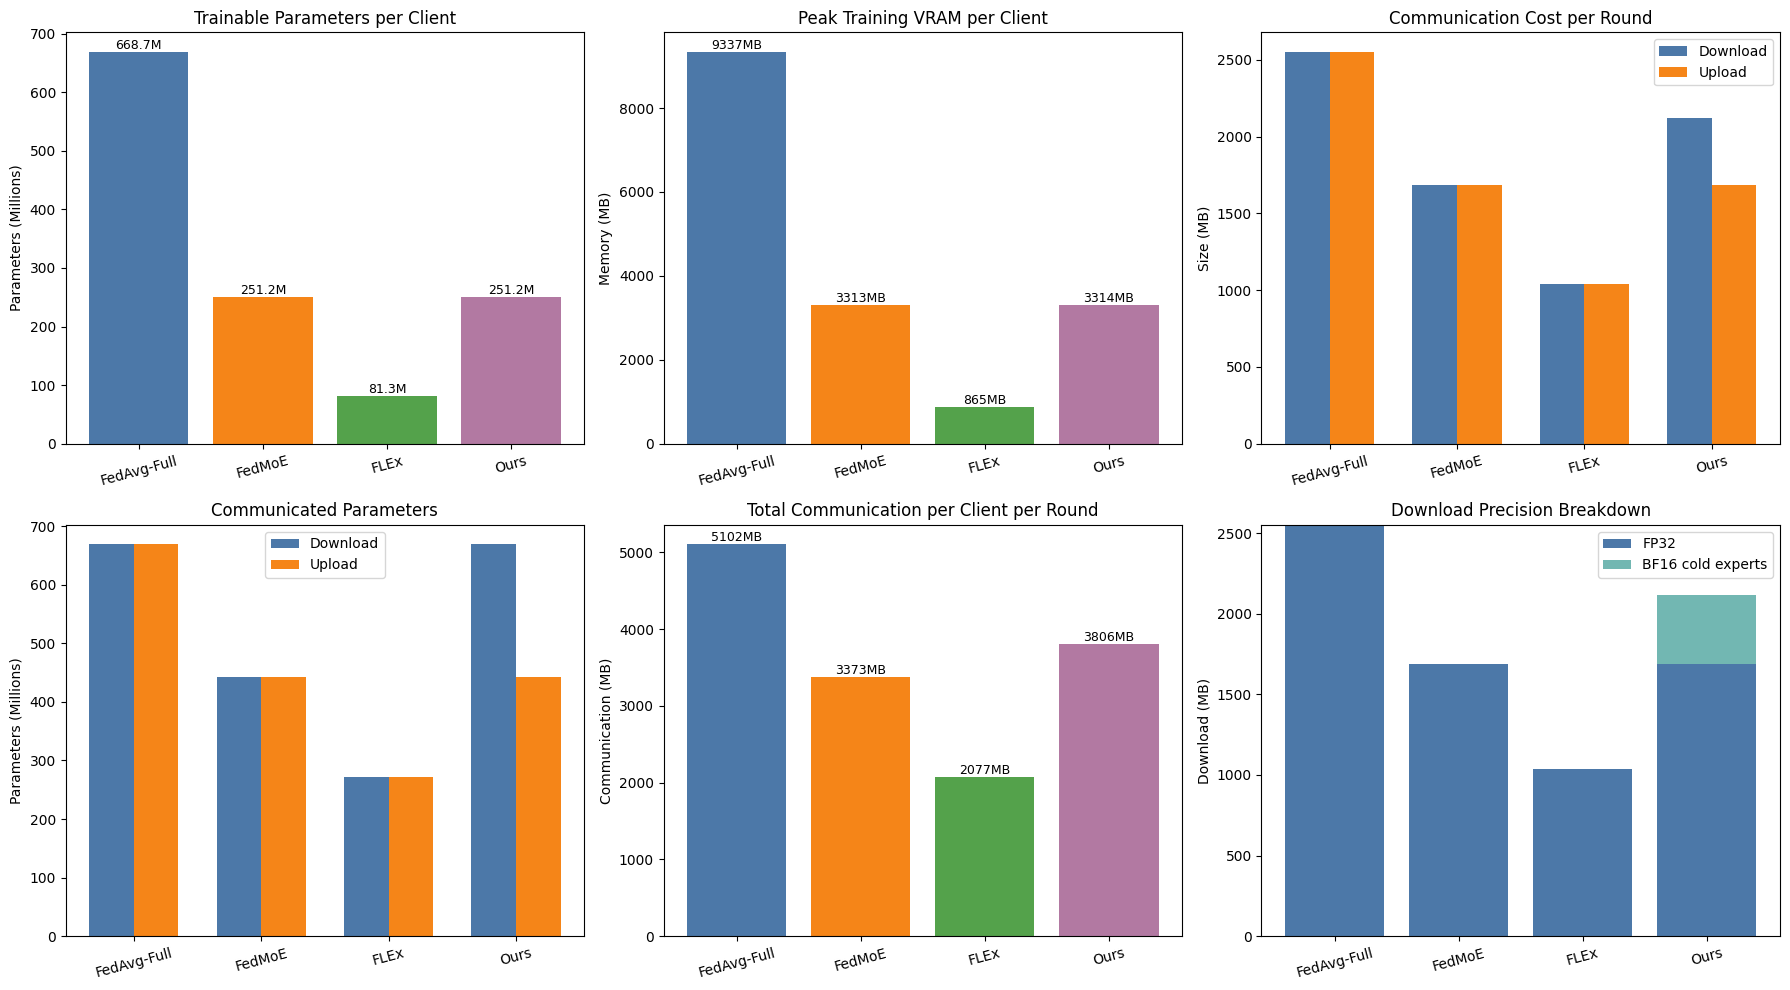


Visualization saved to: memory_communication_profile.png


In [15]:
if not results:
    raise RuntimeError("No profiling results available.")

plot_results = [results[spec["mode"]] for spec in MODE_SPECS if spec["mode"] in results]
mode_labels = [r["mode_label"] for r in plot_results]
colors = ["#4c78a8", "#f58518", "#54a24b", "#b279a2"][: len(plot_results)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Trainable Parameters
ax = axes[0, 0]
trainable_params = [r["model_info"]["trainable_params"] / 1e6 for r in plot_results]
bars = ax.bar(mode_labels, trainable_params, color=colors)
ax.set_ylabel("Parameters (Millions)")
ax.set_title("Trainable Parameters per Client")
for bar, val in zip(bars, trainable_params):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.1f}M", ha="center", va="bottom", fontsize=9)
ax.tick_params(axis="x", rotation=15)

# 2. Peak Memory Usage
ax = axes[0, 1]
peak_memories = [np.nan if r["peak_memory_mb"] is None else r["peak_memory_mb"] for r in plot_results]
bars = ax.bar(mode_labels, peak_memories, color=colors)
ax.set_ylabel("Memory (MB)")
ax.set_title("Peak Training VRAM per Client")
for bar, val in zip(bars, peak_memories):
    if np.isfinite(val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.0f}MB", ha="center", va="bottom", fontsize=9)
ax.tick_params(axis="x", rotation=15)

# 3. Communication - Download vs Upload
ax = axes[0, 2]
x = np.arange(len(mode_labels))
width = 0.35
downloads = [r["communication"]["download_mb"] for r in plot_results]
uploads = [r["communication"]["upload_mb"] for r in plot_results]
ax.bar(x - width / 2, downloads, width, label="Download", color="#4c78a8")
ax.bar(x + width / 2, uploads, width, label="Upload", color="#f58518")
ax.set_ylabel("Size (MB)")
ax.set_title("Communication Cost per Round")
ax.set_xticks(x)
ax.set_xticklabels(mode_labels, rotation=15)
ax.legend()

# 4. Download/Upload Parameters
ax = axes[1, 0]
download_params = [r["communication"]["download_params"] / 1e6 for r in plot_results]
upload_params = [r["communication"]["upload_params"] / 1e6 for r in plot_results]
ax.bar(x - width / 2, download_params, width, label="Download", color="#4c78a8")
ax.bar(x + width / 2, upload_params, width, label="Upload", color="#f58518")
ax.set_ylabel("Parameters (Millions)")
ax.set_title("Communicated Parameters")
ax.set_xticks(x)
ax.set_xticklabels(mode_labels, rotation=15)
ax.legend()

# 5. Total Communication per Round
ax = axes[1, 1]
total_comm = [r["communication"]["total_communication_mb"] for r in plot_results]
bars = ax.bar(mode_labels, total_comm, color=colors)
ax.set_ylabel("Communication (MB)")
ax.set_title("Total Communication per Client per Round")
for bar, val in zip(bars, total_comm):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.0f}MB", ha="center", va="bottom", fontsize=9)
ax.tick_params(axis="x", rotation=15)

# 6. Mix Download Breakdown
ax = axes[1, 2]
download_fp32 = [r["communication"]["download_fp32_mb"] for r in plot_results]
download_bf16 = [r["communication"]["download_bf16_mb"] for r in plot_results]
ax.bar(mode_labels, download_fp32, label="FP32", color="#4c78a8")
ax.bar(mode_labels, download_bf16, bottom=download_fp32, label="BF16 cold experts", color="#72b7b2")
ax.set_ylabel("Download (MB)")
ax.set_title("Download Precision Breakdown")
ax.tick_params(axis="x", rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig("memory_communication_profile.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nVisualization saved to: memory_communication_profile.png")

## Detailed Parameter Breakdown

In [16]:
for spec in MODE_SPECS:
    mode = spec["mode"]
    if mode not in results:
        continue
    result = results[mode]
    comm = result["communication"]
    print(f"\n{'=' * 70}")
    print(f"Mode: {result['mode_label']} (mode={mode}, K={result['k']})")
    print(f"{'=' * 70}")

    param_details = result["model_info"]["param_details"]
    expert_params = [p for p in param_details if is_expert_param(p["name"])]
    router_params = [p for p in param_details if is_router_param(p["name"])]
    other_params = [p for p in param_details if not is_expert_param(p["name"]) and not is_router_param(p["name"])]

    print("\nExpert Parameters:")
    print(f"  Total: {sum(p['numel'] for p in expert_params):,}")
    print(f"  Trainable: {sum(p['numel'] for p in expert_params if p['requires_grad']):,}")
    print(f"  Trainable Size: {sum(p['trainable_mb'] for p in expert_params):.2f} MB")

    print("\nRouter Parameters:")
    print(f"  Total: {sum(p['numel'] for p in router_params):,}")
    print(f"  Trainable: {sum(p['numel'] for p in router_params if p['requires_grad']):,}")
    print(f"  Trainable Size: {sum(p['trainable_mb'] for p in router_params):.2f} MB")

    print("\nOther Parameters:")
    print(f"  Total: {sum(p['numel'] for p in other_params):,}")
    print(f"  Trainable: {sum(p['numel'] for p in other_params if p['requires_grad']):,}")
    print(f"  Trainable Size: {sum(p['trainable_mb'] for p in other_params):.2f} MB")

    print("\nCommunication:")
    print(f"  Download policy: {comm['download_policy']}")
    print(f"  Upload policy: {comm['upload_policy']}")
    print(f"  Download params: {comm['download_params']:,}")
    print(f"  Upload params: {comm['upload_params']:,}")
    print(f"  Download FP32: {comm['download_fp32_params']:,} params, {comm['download_fp32_mb']:.2f} MB")
    print(f"  Download BF16: {comm['download_bf16_params']:,} params, {comm['download_bf16_mb']:.2f} MB")
    print(f"  Upload FP32: {comm['upload_fp32_params']:,} params, {comm['upload_fp32_mb']:.2f} MB")
    print(f"  Excluded from download: {comm['excluded_params']:,} params, {comm['excluded_mb']:.2f} MB")


Mode: FedAvg-Full (mode=full, K=4)

Expert Parameters:
  Total: 452,984,832
  Trainable: 452,984,832
  Trainable Size: 1728.00 MB

Router Parameters:
  Total: 73,728
  Trainable: 73,728
  Trainable Size: 0.28 MB

Other Parameters:
  Total: 215,632,132
  Trainable: 215,632,132
  Trainable Size: 822.57 MB

Communication:
  Download policy: full FP32 model
  Upload policy: full FP32 model
  Download params: 668,690,692
  Upload params: 668,690,692
  Download FP32: 668,690,692 params, 2550.85 MB
  Download BF16: 0 params, 0.00 MB
  Upload FP32: 668,690,692 params, 2550.85 MB
  Excluded from download: 0 params, 0.00 MB

Mode: FedMoE (mode=drop, K=4)

Expert Parameters:
  Total: 226,492,416
  Trainable: 226,492,416
  Trainable Size: 864.00 MB

Router Parameters:
  Total: 36,864
  Trainable: 36,864
  Trainable Size: 0.14 MB

Other Parameters:
  Total: 215,632,132
  Trainable: 24,677,380
  Trainable Size: 94.14 MB

Communication:
  Download policy: shared FP32 params + active FP32 experts
  U

## Save Results to CSV

In [17]:
summary_df.to_csv("memory_communication_summary.csv", index=False)
print("Summary saved to: memory_communication_summary.csv")

detailed_results = []
for spec in MODE_SPECS:
    mode = spec["mode"]
    if mode not in results:
        continue
    result = results[mode]
    comm = result["communication"]
    detailed_results.append({
        "mode": mode,
        "mode_label": result["mode_label"],
        "k": result["k"],
        "total_params": result["model_info"]["total_params"],
        "trainable_params": result["model_info"]["trainable_params"],
        "total_mb": result["model_info"]["total_mb"],
        "trainable_mb": result["model_info"]["trainable_mb"],
        "peak_memory_mb": result["peak_memory_mb"],
        "wall_time_minutes": result["wall_time_minutes"],
        "download_params": comm["download_params"],
        "upload_params": comm["upload_params"],
        "download_fp32_params": comm["download_fp32_params"],
        "download_bf16_params": comm["download_bf16_params"],
        "upload_fp32_params": comm["upload_fp32_params"],
        "download_mb": comm["download_mb"],
        "upload_mb": comm["upload_mb"],
        "total_communication_mb": comm["total_communication_mb"],
        "compression_ratio": comm["compression_ratio"],
        "download_fp32_mb": comm["download_fp32_mb"],
        "download_bf16_mb": comm["download_bf16_mb"],
        "excluded_params": comm["excluded_params"],
        "excluded_mb": comm["excluded_mb"],
        "download_policy": comm["download_policy"],
        "upload_policy": comm["upload_policy"],
    })

pd.DataFrame(detailed_results).to_csv("memory_communication_detailed.csv", index=False)
print("Detailed results saved to: memory_communication_detailed.csv")

Summary saved to: memory_communication_summary.csv
Detailed results saved to: memory_communication_detailed.csv


## Key Findings Summary

In [18]:
print("\n" + "=" * 70)
print("KEY FINDINGS")
print("=" * 70)

if results:
    full = results.get("full")
    if full is None:
        print("FedAvg-Full did not profile, so reductions are unavailable.")
    else:
        full_comm = full["communication"]["total_communication_mb"]
        full_peak = full["peak_memory_mb"]

        print("\n1. PEAK VRAM:")
        for spec in MODE_SPECS:
            mode = spec["mode"]
            if mode not in results:
                continue
            result = results[mode]
            peak = result["peak_memory_mb"]
            if peak is None:
                print(f"   {result['mode_label']}: skipped")
            elif full_peak is not None and mode != "full":
                print(f"   {result['mode_label']}: {peak:.2f} MB ({full_peak / peak:.2f}x smaller than FedAvg-Full)")
            else:
                print(f"   {result['mode_label']}: {peak:.2f} MB")

        print("\n2. COMMUNICATION COST (download + upload per client per round):")
        for spec in MODE_SPECS:
            mode = spec["mode"]
            if mode not in results:
                continue
            result = results[mode]
            comm = result["communication"]
            reduction = full_comm / comm["total_communication_mb"] if comm["total_communication_mb"] else np.nan
            print(
                f"   {result['mode_label']}: {comm['total_communication_mb']:.2f} MB "
                f"(down {comm['download_mb']:.2f} + up {comm['upload_mb']:.2f}, {reduction:.2f}x reduction)"
            )

        print("\n3. COMMUNICATED PARAMETERS:")
        for spec in MODE_SPECS:
            mode = spec["mode"]
            if mode not in results:
                continue
            result = results[mode]
            comm = result["communication"]
            print(
                f"   {result['mode_label']}: down {comm['download_params'] / 1e6:.2f}M params, "
                f"up {comm['upload_params'] / 1e6:.2f}M params"
            )

        print("\n4. MIX DOWNLOAD BREAKDOWN:")
        mix = results.get("mix")
        if mix is not None:
            comm = mix["communication"]
            print(f"   FP32 trainable download: {comm['download_fp32_mb']:.2f} MB")
            print(f"   BF16 cold expert download: {comm['download_bf16_mb']:.2f} MB")
            print(f"   Upload FP32 trainable params: {comm['upload_fp32_mb']:.2f} MB")
else:
    print("No modes profiled. Check errors above.")


KEY FINDINGS

1. PEAK VRAM:
   FedAvg-Full: 9336.79 MB
   FedMoE: 3313.36 MB (2.82x smaller than FedAvg-Full)
   FLEx: 864.94 MB (10.79x smaller than FedAvg-Full)
   Ours: 3313.92 MB (2.82x smaller than FedAvg-Full)

2. COMMUNICATION COST (download + upload per client per round):
   FedAvg-Full: 5101.71 MB (down 2550.85 + up 2550.85, 1.00x reduction)
   FedMoE: 3373.42 MB (down 1686.71 + up 1686.71, 1.51x reduction)
   FLEx: 2077.21 MB (down 1038.61 + up 1038.61, 2.46x reduction)
   Ours: 3805.71 MB (down 2118.85 + up 1686.85, 1.34x reduction)

3. COMMUNICATED PARAMETERS:
   FedAvg-Full: down 668.69M params, up 668.69M params
   FedMoE: down 442.16M params, up 442.16M params
   FLEx: down 272.26M params, up 272.26M params
   Ours: down 668.69M params, up 442.20M params

4. MIX DOWNLOAD BREAKDOWN:
   FP32 trainable download: 1686.85 MB
   BF16 cold expert download: 432.00 MB
   Upload FP32 trainable params: 1686.85 MB
